In [49]:
import os
import matplotlib.pyplot as plt
from tabulate import tabulate

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

In [ ]:
# Number of points generated for the Lorenz time series
npoints = 1000

# Lorenz system parameters
sigma, rho, beta = 10, 28, 8 / 3

# Initial conditions
x, y, z = [0], [-0.01], [9]

# Integration step size
h = 0.01

# Solve the Lorenz system using Euler integration
for _ in range(npoints - 1):
    x_t, y_t, z_t = x[-1], y[-1], z[-1]

    x.append(x_t + h * sigma * (y_t - x_t))
    y.append(y_t + h * (-y_t - z_t * x_t + rho * x_t))
    z.append(z_t + h * (-beta * z_t + x_t * y_t))

# Combine the three coordinates into a single dataset
dataset = np.column_stack((x, y, z))

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = x_val = np.clip(val_scaled, 0, 1)

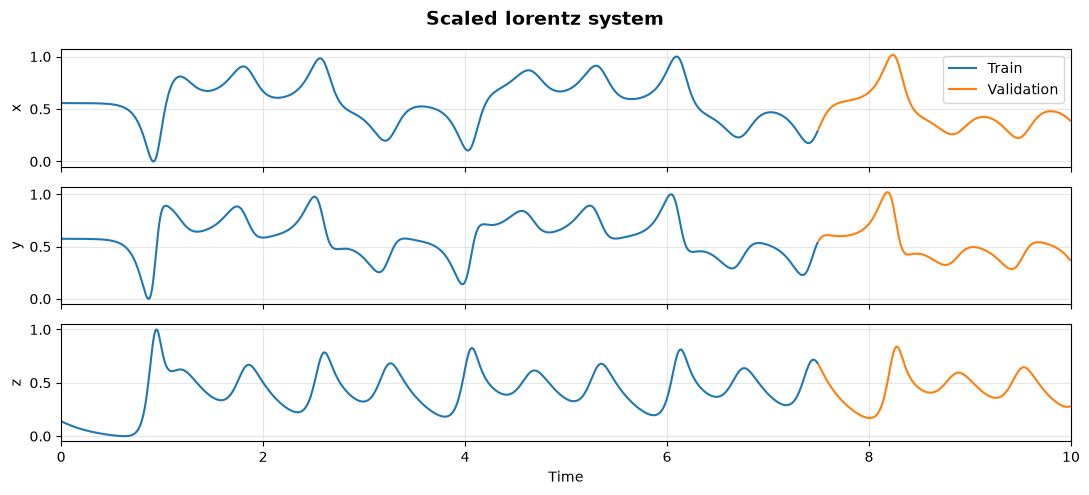

In [ ]:
# Plot the scaled Lorentz system
time = np.arange(npoints) * h
time_tr = time[:len(train_scaled)]
time_test = time[len(train_scaled):]

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)

for ax in axes:
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)


axes[0].plot(time_tr, train_scaled[:, 0], label="Train")
axes[0].plot(time_test, val_scaled[:, 0], label="Validation")
axes[0].legend()
axes[0].set_ylabel("x")

axes[1].plot(time_tr, train_scaled[:, 1])
axes[1].plot(time_test, val_scaled[:, 1])
axes[1].set_ylabel("y")

axes[2].plot(time_tr, train_scaled[:, 2])
axes[2].plot(time_test, val_scaled[:, 2])
axes[2].set_ylabel("z")
axes[2].set_xlabel("Time")
axes[2].set_xlim(0, 10)

fig.suptitle("Scaled lorentz system", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
def create_sequences(data, window_size, horizon):
    """
    Creates input-output sequences for time series forecasting.

    Each input contains the previous window_size points, and each output
    contains the next horizon points to predict.
    """
    n_data = len(data)
    x = []
    y = []

    # Slide a window over the time series
    for i in range(window_size, n_data - horizon + 1):

        # Input sequence: previous window_size points
        x.append(data[i - window_size:i])

        # Target sequence: next horizon points
        y.append(data[i:i + horizon])

    return np.array(x), np.array(y)

# Independent-chanel VQC

First, we will use and independent VQC per each variable. Each VQC will consist on the aplication of a angle encoding feature map $U_{enc}$ and an ansantz $U_{var}(\theta)$. The chosen architectures are angle encoding via $R_y$ rotations for the feature map, and strongly entangling layer with $R_z, R_y, R_z$ rotations and circular entangling layer for the ansatz. Thus, output per chanel will be given by:

$$
Z_c = \langle 0^{\otimes n}|U_{enc}^\dagger U_{var}^\dagger (\theta) Z_0 U_{var} (\theta) U_{enc} |0^{\otimes n} \rangle 
$$

Finally, by collecting all the chanels we obtain the raw quantum output vector:

$$
Z = [Z_1, ... ,Z_C] \in [-1, 1]^C
$$

which can be rescaled to match the normalized data domain by computing:

$$
\hat{Y} = (Z+1)/2
$$

In [26]:
# Create the sequences
window_size = 5
horizon = 1
batch_size = 128

x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

# Convert to tensor
x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

In [27]:
def create_channel_loader(x, y, channel, batch_size=128, shuffle=False):
    """
    Creates a DataLoader for one independent time series channel.
    """
    # Select only one channel
    x_channel = x[:, :, channel] # (n_samples, window_size)
    y_channel = y[:, :, channel] # (n_samples, horizon)

    dataset = TensorDataset(x_channel, y_channel)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return loader

In [28]:
# Create the data loaders
train_loader_x = create_channel_loader(x_tr, hor_tr, channel=0, batch_size=batch_size)
train_loader_y = create_channel_loader(x_tr, hor_tr, channel=1, batch_size=batch_size)
train_loader_z = create_channel_loader(x_tr, hor_tr, channel=2, batch_size=batch_size)

In [29]:
def angle_encoding(nqubits: int, inputs: list[float]) -> None:
    """
    Encodes classical input data into a quantum circuit using angle encoding 
    by applying Ry rotations with angle pi * input[i]
    """
    # Encode each classical value into one qubit
    for i in range(nqubits):
        qml.RY(np.pi * inputs[..., i], wires=i)

def QVC(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a variational quantum circuit.

    Each layer applies three parameterized rotations to every qubit:
    Rz -> Ry -> Rz.

    After the rotation block, a circular CNOT entangling layer is applied.
    """
    for rep in range(reps):
        # Rotation block
        for i in range(nqubits):
            base = rep * 3 * nqubits
            qml.RZ(theta[base + i], wires=i)
            qml.RY(theta[base + nqubits + i], wires=i)
            qml.RZ(theta[base + 2 * nqubits + i], wires=i)
        
        # Entangling block
        for i in range(nqubits-1):
            qml.CNOT(wires=[i, i+1])
        
        # Circular connection between last and first qubit
        qml.CNOT(wires=[nqubits-1, 0])

In [30]:
# Create the PennyLane QNode 
nqubits = window_size
nreps = 24
dev = qml.device("lightning.qubit", wires=nqubits)

def indep_chanel_vqc(inputs, theta):
    angle_encoding(nqubits, inputs)
    QVC(nqubits, theta, nreps)
    return qml.expval(qml.Z(0))

indep_chanel_vqc_node = qml.QNode(
    func=indep_chanel_vqc,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [ ]:
# Shape of the trainable parameters used inside the quantum circuitval_x
weights = {"theta": (3 * nqubits * nreps,)}

# Convert the PennyLane QNode into PyTorch layers
qlayer_x = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
qlayer_y = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
qlayer_z = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

# Rescale the data
class RescaledQuantumModel(nn.Module):
    def __init__(self, qlayer):
        super().__init__()
        self.qlayer = qlayer

    def forward(self, x):
        z = self.qlayer(x)
        return (z + 1) / 2


# Build one independent model for each Lorenz channel
model_x = RescaledQuantumModel(qlayer_x)
model_y = RescaledQuantumModel(qlayer_y)
model_z = RescaledQuantumModel(qlayer_z)

# Use double precision for compatibility with PennyLane
model_x.double()
model_y.double()
model_z.double()


# Select each channel independently
val_x = x_val[:, :, 0]  # shape: (n_samples, window_size)
val_y = x_val[:, :, 1]
val_z = x_val[:, :, 2]

val_hor_x = hor_val[:, :, 0]  # shape: (n_samples, horizon)
val_hor_y = hor_val[:, :, 1]
val_hor_z = hor_val[:, :, 2]


In [32]:
# Hyperparameters
epochs = 50
lr = 5e-4

# Mean squared error loss for regression
loss_fn = nn.MSELoss()

# Group loaders, validation datasets and models to train the three channels in the same loop
loaders = (train_loader_x, train_loader_y, train_loader_z)
models = (model_x, model_y, model_z)
test_windows = (val_x, val_y, val_z)
test_horizons = (val_hor_x, val_hor_y, val_hor_z)

# Save the best model
best_state = None
best_val_loss = float("inf")
histories = []

for loader, model, test_window, test_hor in zip(loaders, models, test_windows, test_horizons):
    print(30 * "#")
    print("Starting training")
    print(30 * "#")

    history = {"Loss": [], "Val loss": []}

    # Define optimizer
    opt = torch.optim.Adam(params=model.parameters(), lr=lr)

    for epoch in range(epochs):

        #Training
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb.squeeze())
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        
        # Store average loss for this epoch
        epoch_loss /= len(loader)
        history["Loss"].append(epoch_loss)

        # Evaluation
        model.eval()
        with torch.no_grad():
            val_pred = model(test_window)
            val_loss = loss_fn(val_pred, test_hor.squeeze()).item()

        # Store val loss
        history["Val loss"].append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                name: params.detach().clone()
                for name, params in model.state_dict().items()
            }

        # Print training progress every 5 epochs
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")

    histories.append(history)
    if best_state is not None:
        model.load_state_dict(best_state)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0614 | Validation loss: 0.0357
Epoch: 5 | Loss: 0.0276 | Validation loss: 0.0197
Epoch: 10 | Loss: 0.0118 | Validation loss: 0.0109
Epoch: 15 | Loss: 0.0070 | Validation loss: 0.0075
Epoch: 20 | Loss: 0.0050 | Validation loss: 0.0055
Epoch: 25 | Loss: 0.0038 | Validation loss: 0.0041
Epoch: 30 | Loss: 0.0031 | Validation loss: 0.0033
Epoch: 35 | Loss: 0.0026 | Validation loss: 0.0027
Epoch: 40 | Loss: 0.0023 | Validation loss: 0.0023
Epoch: 45 | Loss: 0.0020 | Validation loss: 0.0020
Epoch: 50 | Loss: 0.0018 | Validation loss: 0.0018
##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0480 | Validation loss: 0.0271
Epoch: 5 | Loss: 0.0212 | Validation loss: 0.0136
Epoch: 10 | Loss: 0.0091 | Validation loss: 0.0066
Epoch: 15 | Loss: 0.0058 | Validation loss: 0.0047
Epoch: 20 | Loss: 0.0044 | Validation loss: 0.0037
Epoch: 25 | Loss: 0.0035 | V

In [50]:
# Save the models
os.makedirs("models", exist_ok=True)

checkpoint = {
    "model_x": model_x.state_dict(),
    "model_y": model_y.state_dict(),
    "model_z": model_z.state_dict(),

    # Important hyperparameters needed to rebuild the models
    "window_size": window_size,
    "horizon": horizon,
    "nqubits": nqubits,
    "nreps": nreps,
}

torch.save(checkpoint, "models/independent_channel_vqc.pt")

In [ ]:
# Load the models
checkpoint = torch.load(
    "models/independent_channel_vqc.pt",
    map_location="cpu"
)

window_size = checkpoint["window_size"]
horizon = checkpoint["horizon"]
nqubits = checkpoint["nqubits"]
nreps = checkpoint["nreps"]

model_x = IndependentChannelVQC(nqubits=nqubits, reps=nreps).double()
model_y = IndependentChannelVQC(nqubits=nqubits, reps=nreps).double()
model_z = IndependentChannelVQC(nqubits=nqubits, reps=nreps).double()

model_x.load_state_dict(checkpoint["model_x"])
model_y.load_state_dict(checkpoint["model_y"])
model_z.load_state_dict(checkpoint["model_z"])

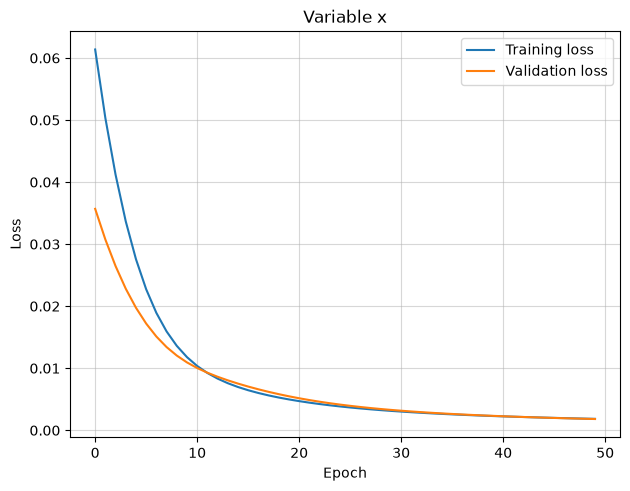

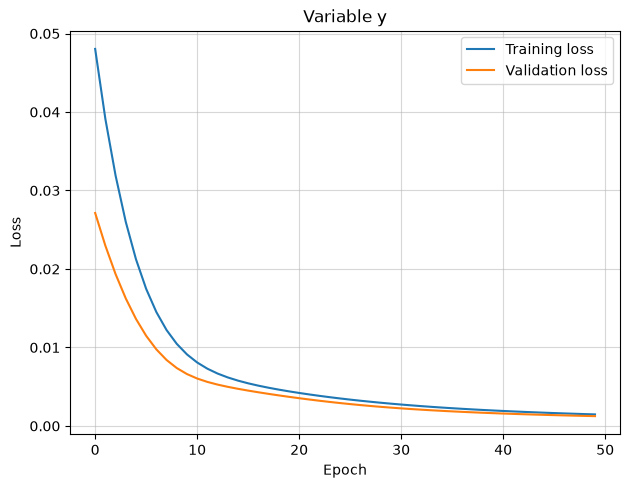

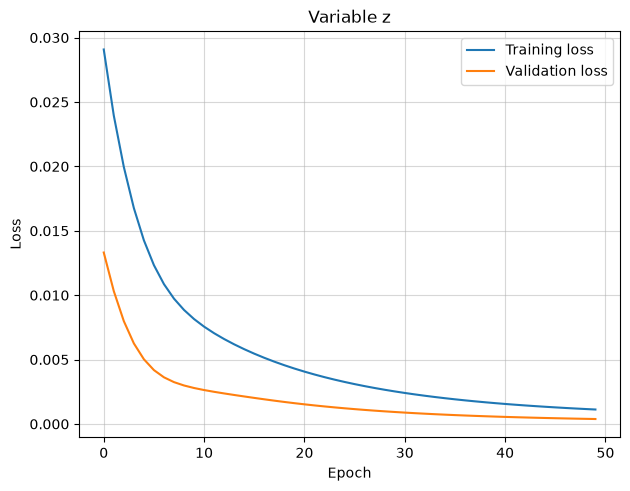

In [48]:
def plot_loss(history, title = None) -> None:
    """
    Plots the training loss curve from the history of a model
    """
    plt.plot(history["Loss"], label="Training loss")
    plt.plot(history["Val loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.show()

plot_loss(histories[0], "Variable x")
plot_loss(histories[1], "Variable y")
plot_loss(histories[2], "Variable z")

In [37]:
# Evaluation mode
model_x.eval()
model_y.eval()
model_z.eval()

with torch.no_grad():
    pred_x = model_x(val_x).reshape(-1, 1)
    pred_y = model_y(val_y).reshape(-1, 1)
    pred_z = model_z(val_z).reshape(-1, 1)

# Stack predictions and targets: (n_samples, horizon, channels)
pred = torch.stack([pred_x, pred_y, pred_z], dim=2)
target = torch.stack([val_hor_x, val_hor_y, val_hor_z], dim=2)

# =====================
# RMSE
# =====================

squared_error = (pred - target) ** 2

# Per-sample RMSE, averaged over horizon and channels
mean_rmse_list = torch.sqrt(squared_error.mean(dim=(1, 2)))

# Global RMSE
mean_rmse_1 = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred - target)

# Per-sample MAE, averaged over horizon and channels
mean_mae_list = abs_error.mean(dim=(1, 2))

# Global MAE
mean_mae_1 = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target - pred) / (target + eps))

# Per-sample MAPE, averaged over horizon and channels
mean_mape_list = percentage_error.mean(dim=(1, 2))

# Global MAPE
mean_mape_1 = percentage_error.mean()

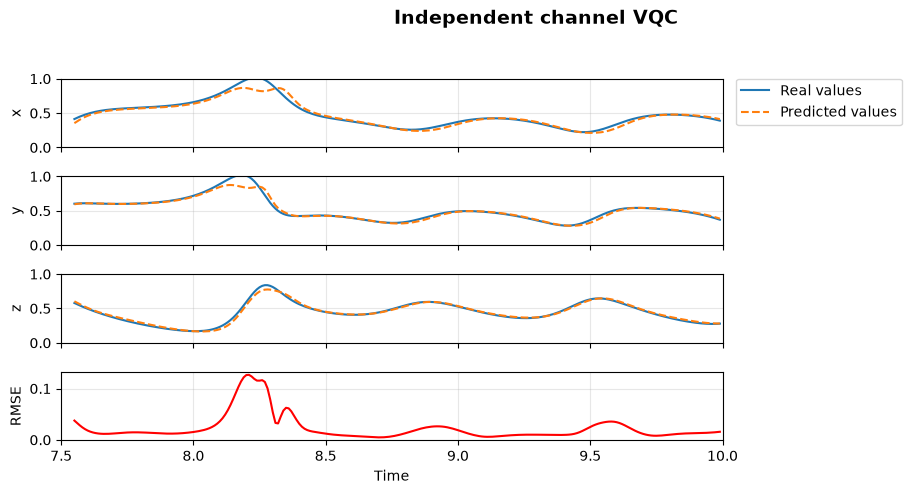

In [45]:
def plot_preds_and_error(pred_x, pred_y, pred_z, mean_error_total, error, title=None):
    """
    Plots real and predicted values for the three Lorenz channels.

    The last subplot shows the mean prediction error over time.
    """
    # Create one subplot for each channel and one for the error
    fig, axes = plt.subplots(4, 1, figsize=(11, 5), sharex=True)

    # Time values aligned with predictions
    time_pred = time_test[window_size:window_size + len(pred_x)]

    # Real values aligned with predictions
    real_x = val_scaled[window_size:window_size + len(pred_x), 0]
    real_y = val_scaled[window_size:window_size + len(pred_y), 1]
    real_z = val_scaled[window_size:window_size + len(pred_z), 2]

    # Grid and ylim
    for ax in axes[:-1]:
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

    # Plot x channel
    axes[0].plot(time_pred, real_x, label="Real values")
    axes[0].plot(time_pred, pred_x, label="Predicted values", linestyle="--")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    axes[0].set_ylabel("x")

    # Plot y channel
    axes[1].plot(time_pred, real_y, label="Real values")
    axes[1].plot(time_pred, pred_y, label="Predicted values", linestyle="--")
    axes[1].set_ylabel("y")

    # Plot z channel
    axes[2].plot(time_pred, real_z, label="Real values")
    axes[2].plot(time_pred, pred_z, label="Predicted values", linestyle="--")
    axes[2].set_ylabel("z")

    # Plot mean prediction error
    axes[3].plot(time_pred, mean_error_total, color="red", label="Mean error")
    axes[3].set_ylabel(error)
    axes[3].set_xlabel("Time")
    axes[3].grid(alpha=0.3)

    axes[3].set_xlim(7.5, 10)

    if title is not None:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()
    
plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_rmse_list,
    error = "RMSE",
    title="Independent channel VQC"
)

In [46]:
# Create a table to summarize the results
headers = ["Model", "MAPE", "MAE", "RMSE"]
results = [["VQC (indep.)", mean_mape_1, mean_mae_1, mean_rmse_1]]

print(30*"#")
print("Short term forecasting")
print(30*"#")
print(tabulate(results, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))

##############################
Short term forecasting
##############################
╒══════════════╤════════╤════════╤════════╕
│ Model        │   MAPE │    MAE │   RMSE │
╞══════════════╪════════╪════════╪════════╡
│ VQC (indep.) │ 0.0399 │ 0.0199 │ 0.0339 │
╘══════════════╧════════╧════════╧════════╛


# VQC combined with MLP

In this section, we will use the same indepent-chanel architecture we used before and post-process it by appending a two-layer perceptron. We will use the RELU function and the mapping will be:

$$
\phi_{mlp}  :\mathbb{R^C} \rightarrow \mathbb{R^{2C\times S}} \rightarrow \mathbb{R^{C\times S}}
$$

This architecture supperts forecasting horizons $S>1$ simply by adjusting the output dimension of the final layer.

In [ ]:
# Create the MLP post-processing model
class VQCMLPModel(nn.Module):
    def __init__(self, chanels, horizon):
        super().__init__()

        self.vqc_x = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_y = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_z = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

        self.mlp = nn.Sequential(
            nn.Linear(chanels, 2*chanels*horizon),   
            nn.ReLU(),
            nn.Linear(2*chanels*horizon, chanels*horizon)     
        )

    def forward(self, x):
        # x shape: (batch, window_size, channels)
        x_ch = x[:, :, 0]
        y_ch = x[:, :, 1]
        z_ch = x[:, :, 2]

        qx = self.vqc_x(x_ch)
        qy = self.vqc_y(y_ch)
        qz = self.vqc_z(z_ch)

        q_features = torch.stack([qx, qy, qz], dim=1)

        return self.mlp(q_features)

## Short term forecasting

In [ ]:
# Create the sequences
window_size = 5
horizon_short = 1
batch_size = 128
n_chanels = 3

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [ ]:
# Hyperparameters
epochs = 50
lr = 5e-4

# Create the model
model_VQCMLP_short = VQCMLPModel(n_chanels, horizon_short)
model_VQCMLP_short.double()

# Define optimizer and loss function
opt = torch.optim.Adam(params=model_VQCMLP_short.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_VQCMLP_short.train()
    epoch_loss = 0
    for xb, yb in tr_loader_short:
        opt.zero_grad()
        pred = model_VQCMLP_short(xb).squeeze()
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_short)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_VQCMLP_short.eval()
    with torch.no_grad():
        val_pred = model_VQCMLP_short(x_val_short)
        val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_VQCMLP_short.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_VQCMLP_short.load_state_dict(best_state)

# Long term forecasting

In [ ]:
# Create the sequences
window_size = 5
horizon_long = 5
batch_size = 128
n_chanels = 3

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [ ]:
# Hyperparameters
epochs = 50
lr = 5e-4

# Create the model
model_VQCMLP_long = VQCMLPModel(n_chanels, horizon_long)
model_VQCMLP_long.double()

# Define optimizer and loss function
opt = torch.optim.Adam(params=model_VQCMLP_long.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state = None
best_val_loss = float("inf")

history = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_VQCMLP_long.train()
    epoch_loss = 0
    for xb, yb in tr_loader_long:
        opt.zero_grad()
        pred = model_VQCMLP_long(xb).squeeze() # shape: (batch, 15)
        target = yb.reshape(yb.shape[0], -1) # yb shape: (batch, 5, 3)
        loss = loss_fn(pred, target)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_long)
    history["Loss"].append(epoch_loss)

    # Evaluation
    model_VQCMLP_long.eval()
    with torch.no_grad():
        val_pred = model_VQCMLP_long(x_val_long)
        val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name: params.detach().clone()
            for name, params in model_VQCMLP_long.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state is not None:
    model_VQCMLP_long.load_state_dict(best_state)